<a href="https://colab.research.google.com/github/gideonadeti/learning-machine-learning/blob/main/Deep_Q_Network_(DQN)_Tutorial_Solving_CartPole_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary packages
!pip install gymnasium torch matplotlib numpy

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
from tqdm import tqdm  # optional, for progress bars

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
set_seed()

In [3]:
env = gym.make("CartPole-v1")
print("State space:", env.observation_space)
print("Action space:", env.action_space)
print("Example state:", env.reset()[0])
env.close()

State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Example state: [ 0.03578941 -0.02252172 -0.03520217  0.0187468 ]


In [4]:
# MDP definition (for clarity)
STATE_DIM = env.observation_space.shape[0]   # 4
ACTION_DIM = env.action_space.n              # 2
GAMMA = 0.99                                 # discount factor

In [5]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # raw Q-values for each action

In [6]:
policy_net = DQN(STATE_DIM, ACTION_DIM)
target_net = DQN(STATE_DIM, ACTION_DIM)
target_net.load_state_dict(policy_net.state_dict())  # initialise identical
target_net.eval()  # target network is only used for inference

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)

In [7]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

In [8]:
def train_step(batch_size):
    if len(replay_buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # Convert to tensors
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)  # shape: (batch, 1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1) # (batch, 1)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones).unsqueeze(1)     # (batch, 1)

    # Compute current Q-values for taken actions
    current_q = policy_net(states).gather(1, actions)  # (batch, 1)

    # Compute target Q-values using target network
    with torch.no_grad():
        next_q = target_net(next_states).max(1, keepdim=True)[0]  # (batch, 1)
        target_q = rewards + GAMMA * next_q * (1 - dones)

    # Loss
    loss = F.mse_loss(current_q, target_q)

    # Optimise
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [9]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()  # random action
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            q_values = policy_net(state_tensor)
            return q_values.argmax().item()

In [10]:
REPLAY_CAPACITY = 10000
BATCH_SIZE = 64
TARGET_UPDATE_FREQ = 10      # update target network every 10 episodes (or steps)
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995        # multiplicative decay per episode
NUM_EPISODES = 500
MAX_STEPS_PER_EPISODE = 500

In [11]:
replay_buffer = ReplayBuffer(REPLAY_CAPACITY)
episode_rewards = []
epsilon = EPSILON_START

for episode in tqdm(range(NUM_EPISODES), desc="Training episodes"):
    state, _ = env.reset()
    total_reward = 0
    done = False

    for step in range(MAX_STEPS_PER_EPISODE):
        action = select_action(state, epsilon)
        next_state, reward, done, truncated, _ = env.step(action)
        done = done or truncated  # if truncated, it's also terminal

        replay_buffer.push(state, action, reward, next_state, done)
        train_step(BATCH_SIZE)

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    # Update target network periodically
    if episode % TARGET_UPDATE_FREQ == 0:
        target_net.load_state_dict(policy_net.state_dict())

env.close()
print("Training completed!")

Training episodes: 100%|██████████| 500/500 [02:21<00:00,  3.54it/s]

Training completed!


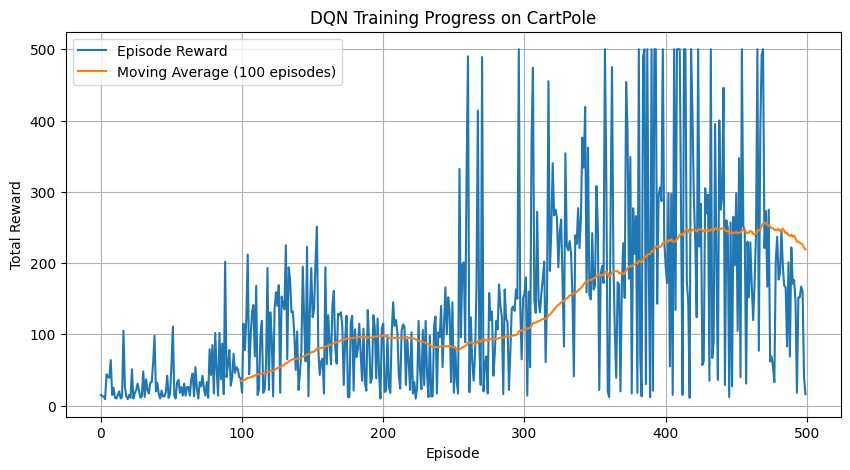

In [12]:
def plot_rewards(rewards, window=100):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label='Episode Reward')
    # moving average
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(np.arange(window-1, len(rewards)), moving_avg, label=f'Moving Average ({window} episodes)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('DQN Training Progress on CartPole')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_rewards(episode_rewards)

In [13]:
def test_agent(num_episodes=5):
    env_test = gym.make("CartPole-v1", render_mode="human")  # use "rgb_array" for Colab, or just run without render
    for i in range(num_episodes):
        state, _ = env_test.reset()
        total_reward = 0
        done = False
        while not done:
            action = select_action(state, epsilon=0.0)  # fully greedy
            state, reward, done, truncated, _ = env_test.step(action)
            done = done or truncated
            total_reward += reward
        print(f"Test Episode {i+1}: Total Reward = {total_reward}")
    env_test.close()

# If you are in a Colab notebook without a display, you can omit render_mode.
# You can also visualise using `render_mode="rgb_array"` and capture frames.
# For simplicity, we'll just print rewards.
test_agent()

Test Episode 1: Total Reward = 180.0
Test Episode 2: Total Reward = 500.0
Test Episode 3: Total Reward = 255.0
Test Episode 4: Total Reward = 204.0
Test Episode 5: Total Reward = 231.0


### DQN Training Summary & Key Takeaways

1.  **Hyperparameter Sensitivity**: Reinforcement Learning is highly sensitive. Small changes in the Learning Rate or Epsilon Decay can be the difference between a failing agent and a perfect score of 500.
2.  **Stability Mechanisms**: Without **Experience Replay** (to break correlation) and the **Target Network** (to provide stable targets), the Q-values would likely oscillate or diverge.

In [19]:
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
from gymnasium.wrappers import RecordVideo

def record_multiple_episodes(env_name, num_episodes=5):
    # We'll create a new folder for these multiple runs
    !mkdir -p multi_video
    trigger = lambda x: True

    env = gym.make(env_name, render_mode="rgb_array")
    # The RecordVideo wrapper will automatically increment names (episode-0, episode-1, etc.)
    env = RecordVideo(env, video_folder="multi_video", episode_trigger=trigger, disable_logger=True)

    for i in range(num_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = select_action(state, epsilon=0.0) # Fully greedy for testing
            state, reward, done, truncated, _ = env.step(action)
            done = done or truncated

    env.close()
    print(f"Recorded {num_episodes} episodes in /multi_video")

# Record 5 distinct runs to see consistency
record_multiple_episodes("CartPole-v1", num_episodes=5)

# List the files so you can see them
import os
print("Available videos:", sorted(os.listdir("multi_video")))

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/multi_video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Recorded 5 episodes in /multi_video
Available videos: ['rl-video-episode-0.mp4', 'rl-video-episode-1.mp4', 'rl-video-episode-2.mp4', 'rl-video-episode-3.mp4', 'rl-video-episode-4.mp4']


In [25]:
def show_specific_video(episode_num=0):
    video_path = f'multi_video/rl-video-episode-{episode_num}.mp4'
    if os.path.exists(video_path):
        video = io.open(video_path, 'r+b').read()
        encoded = base64.b64encode(video)
        print(f"Displaying Episode {episode_num}")
        ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print(f"Video for episode {episode_num} not found.")

# Change this index (0-4) to view different recorded episodes
show_specific_video(episode_num=2)

Displaying Episode 2
